In [1]:
%pip install -q datasets sacrebleu scikit-learn tqdm pandas matplotlib requests

import os, re, json, time, math, random
from collections import Counter
import numpy as np, pandas as pd, requests, torch, torch.nn as nn, torch.nn.functional as F
import matplotlib.pyplot as plt
from tqdm.auto import tqdm
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
import sacrebleu

torch.set_num_threads(os.cpu_count())
random.seed(42); np.random.seed(42); torch.manual_seed(42)

# ===== SETTINGS =====
H_TURNS, H_MAXLEN, D_MAXLEN, R_MAXLEN = 3, 40, 60, 25   # history turns/tokens, doc tokens, response tokens
VOCAB_MAX, EMB, HID = 8000, 128, 256
BS, EPOCHS, LR, PATIENCE = 64, 12, 2e-3, 3
TIME_BUDGET_MIN = 6            # har model ke liye
MERGE_SAME_SPEAKER = True
# ====================
print("threads:", torch.get_num_threads())


[notice] A new release of pip is available: 24.0 -> 26.2.1
[notice] To update, run: c:\Users\shrey\AppData\Local\Programs\Python\Python311\python.exe -m pip install --upgrade pip


Note: you may need to restart the kernel to use updated packages.
threads: 12


c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from datasets import load_dataset
ds = load_dataset("festvox/cmu_hinglish_dog")
print(ds)
print(ds["train"][0])

# Documents HF me nahi hain -> GitHub repo se download (ek baar, phir local cache)
DOC_DIR = "wikidata"; os.makedirs(DOC_DIR, exist_ok=True)
if not os.listdir(DOC_DIR):
    api = "https://api.github.com/repos/festvox/datasets-CMU_DoG/contents/WikiData"
    for f in tqdm(requests.get(api).json(), desc="download docs"):
        open(os.path.join(DOC_DIR, f["name"]), "wb").write(requests.get(f["download_url"]).content)

docs_raw = {}
for fn in os.listdir(DOC_DIR):
    if fn.endswith(".json"):
        d = json.load(open(os.path.join(DOC_DIR, fn), encoding="utf-8"))
        docs_raw[int(d.get("wikiDocumentIdx", os.path.splitext(fn)[0]))] = d
print("docs:", len(docs_raw), "| ids:", sorted(docs_raw)[:5], "...")

k0 = next(iter(docs_raw))
print("top-level keys:", {k: type(v).__name__ for k, v in docs_raw[k0].items()})
print("section 0 keys:", list(docs_raw[k0]["0"].keys()) if isinstance(docs_raw[k0]["0"], dict) else type(docs_raw[k0]["0"]))

c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hub\file_download.py:149: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\shrey\.cache\huggingface\hub\datasets--festvox--cmu_hinglish_dog. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
c:\Users\shrey\AppData\Local\Programs\Python\Python311\Lib\site-packages\huggingface_hu

DatasetDict({
    train: Dataset({
        features: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx'],
        num_rows: 8060
    })
    test: Dataset({
        features: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx'],
        num_rows: 960
    })
    validation: Dataset({
        features: ['date', 'docIdx', 'translation', 'uid', 'utcTimestamp', 'rating', 'status', 'uid1LogInTime', 'uid1LogOutTime', 'uid1response', 'uid2response', 'user2_id', 'whoSawDoc', 'wikiDocumentIdx'],
        num_rows: 942
    })
})
{'date': '2018-03-16T20:49:27.955Z', 'docIdx': 0, 'translation': {'en': 'hi', 'hi_en': 'hi'}, 'uid': 'user1', 'utcTimestamp': '2018-03-16T20:49:39.626Z', 'rating': 2, 'status': 1, 'uid1LogInTime': '2018-03-1

download docs: 100%|██████████| 30/30 [00:24<00:00,  1.24it/s]


docs: 30 | ids: [0, 1, 2, 3, 4] ...
top-level keys: {'0': 'dict', '1': 'str', '2': 'str', '3': 'str', 'wikiDocumentIdx': 'int'}
section 0 keys: ['cast', 'critical_response', 'director', 'genre', 'introduction', 'movieName', 'rating', 'year']


In [3]:
HI_MAP = {"hain": "hai", "hein": "hai", "hei": "hai", "nahin": "nahi", "nhi": "nahi", "achha": "acha",
          "accha": "acha", "achcha": "acha", "tho": "toh", "kyu": "kyun", "kyon": "kyun", "hun": "hoon", "han": "haan"}
URL = re.compile(r"https?://\S+|www\.\S+")
TOK = re.compile(r"[a-z0-9\u0900-\u097f]+(?:'[a-z]+)?|[^\sa-z0-9\u0900-\u097f]")

def norm_tokens(text):
    t = URL.sub(" url ", str(text).lower().replace("’", "'"))
    t = re.sub(r"(.)\1{2,}", r"\1\1", t)                 # soooo -> soo, ????? -> ??
    return [HI_MAP.get(w, w) for w in TOK.findall(t)]

print(norm_tokens("Haan yaar!!! ye movie sooooo acchi hein, check www.imdb.com"))

['haan', 'yaar', '!', '!', 'ye', 'movie', 'soo', 'acchi', 'hai', ',', 'check', 'url']


In [4]:
# ---- Language tagging: EN words = wo words jo English (`en`) side me aate hain ----
train_df = ds["train"].to_pandas()
en_cnt = Counter(w for t in train_df["translation"] for w in norm_tokens(t["en"]))
AMBIG = {"main", "to", "hi", "me", "he", "ho", "do", "par", "is", "us", "na", "are", "be"}   # Hindi/English homographs -> neutral
ALPHA = re.compile(r"[a-z']+")
EN_WORDS = {w for w, c in en_cnt.items() if c >= 3 and ALPHA.fullmatch(w)} - AMBIG

def lang_counts(toks):
    ne = sum(w in EN_WORDS for w in toks)
    nh = sum((w not in EN_WORDS) and (w not in AMBIG) and bool(ALPHA.fullmatch(w)) for w in toks)
    return ne, nh

def cmi(toks):                        # Code-Mixing Index: 0 = monolingual, ~50 = balanced mix
    ne, nh = lang_counts(toks); n = ne + nh
    return 0.0 if n == 0 or min(ne, nh) == 0 else 100 * (1 - max(ne, nh) / n)

def mix_group(toks):
    ne, nh = lang_counts(toks); n = ne + nh
    if n < 3: return "short"
    f = ne / n
    return "mostly-EN" if f >= 0.75 else ("mostly-HI" if f < 0.25 else "mixed")

print(len(EN_WORDS), "EN words")
for s in ["tumne konsi movie dekhi", "it is a great movie", "wo batman kaise ban jata hai", "haan"]:
    t = norm_tokens(s); print(s, "->", mix_group(t), f"CMI={cmi(t):.0f}")

2480 EN words
tumne konsi movie dekhi -> mixed CMI=25
it is a great movie -> mostly-EN CMI=0
wo batman kaise ban jata hai -> mostly-HI CMI=17
haan -> short CMI=0


In [5]:
def flat(x):
    if isinstance(x, str): return x
    if isinstance(x, dict): return " . ".join(flat(v) for v in x.values())
    if isinstance(x, (list, tuple)): return " . ".join(flat(v) for v in x)
    return str(x)

def doc_text(widx, sec):
    d = docs_raw[widx]; s0 = d.get("0") if isinstance(d.get("0"), dict) else {}
    name = flat(s0.get("movieName", ""))
    if sec == 0:
        keys = ["movieName", "year", "director", "genre", "introduction", "rating", "critical_response", "cast"]
        parts = [flat(s0.get(k, "")) for k in keys]
    else:
        parts = [flat(d.get(str(sec), ""))]
    return name, " . ".join(p for p in parts if p.strip())

SENT = re.compile(r"(?<=[.!?])\s+")
doc_sents = {}                                    # (widx, sec) -> (name_tokens, [sentence_tokens])
for w in docs_raw:
    for sec in range(4):
        name, txt = doc_text(w, sec)
        ss = [norm_tokens(s) for s in SENT.split(txt) if s.strip()]
        doc_sents[(w, sec)] = (norm_tokens(name), [s for s in ss if s])

DOCSET = {k: set(nm) | {w for s in ss for w in s} for k, (nm, ss) in doc_sents.items()}
N_SENT = sum(len(ss) for _, ss in doc_sents.values())
DF = Counter(w for _, ss in doc_sents.values() for s in ss for w in set(s))
idf = lambda w: math.log((N_SENT + 1) / (DF.get(w, 0) + 1)) + 1

In [6]:
def select_doc(widx, sec, query_tokens, topk=3):
    if (widx, sec) not in doc_sents: return ["<unk>"]
    name, ss = doc_sents[(widx, sec)]
    q = set(query_tokens)
    order = sorted(range(len(ss)), key=lambda i: -sum(idf(w) for w in set(ss[i]) & q))
    out = name[:6] + ["<sep>"]
    for i in sorted(order[:topk]): out += ss[i][:30]
    return (out or ["<unk>"])[:D_MAXLEN]

print("sentences in all docs:", N_SENT)
print(" ".join(select_doc(k0, 0, norm_tokens("who is the director and what is the cast"))))

sentences in all docs: 1505
batman begins <sep> batman begins is a 2005 superhero film based on the dc comics character batman , directed by christopher nolan and written by nolan and david s . the film reboots the batman film series , telling the origin story of bruce wayne from the death of his parents to his journey to become batman and his fight


In [7]:
def build_convs(split):
    df = ds[split].to_pandas()
    key = ["date", "user2_id", "wikiDocumentIdx"]
    df["cid"] = df[key].ne(df[key].shift()).any(axis=1).cumsum()     # consecutive rows = ek conversation
    convs = []
    for _, g in df.groupby("cid", sort=False):
        turns = []
        for r in g.itertuples():
            hi = norm_tokens(r.translation["hi_en"])
            if not hi: continue
            en = str(r.translation["en"])
            if MERGE_SAME_SPEAKER and turns and turns[-1]["uid"] == r.uid:
                turns[-1]["hi"] += hi; turns[-1]["en"] += " " + en; turns[-1]["sec"] = int(r.docIdx)
            else:
                turns.append(dict(uid=r.uid, hi=hi, en=en, sec=int(r.docIdx),
                                  saw=(r.uid in list(r.whoSawDoc)), widx=int(r.wikiDocumentIdx)))
        convs.append(turns)
    return convs

def make_samples(convs):
    out = []
    for turns in convs:
        for i in range(1, len(turns)):
            hs, t = turns[max(0, i - H_TURNS):i], turns[i]
            hist = []
            for x in hs: hist += x["hi"] + ["<sep>"]
            hist = hist[:-1][-H_MAXLEN:]
            q = norm_tokens(" ".join(x["en"] for x in hs[-2:]))      # doc selection ke liye query
            out.append(dict(hist=hist, resp=t["hi"][:R_MAXLEN], widx=t["widx"], sec=t["sec"], saw=t["saw"],
                            doc=select_doc(t["widx"], t["sec"], q)))
    return out

convs = {sp: build_convs(sp) for sp in ["train", "validation", "test"]}
train_s, val_s, test_s = (make_samples(convs[sp]) for sp in ["train", "validation", "test"])
print({sp: len(c) for sp, c in convs.items()}, "conversations")
print("samples:", len(train_s), len(val_s), len(test_s))

s = train_s[10]
print("HIST:", " ".join(s["hist"])); print("DOC :", " ".join(s["doc"])); print("RESP:", " ".join(s["resp"]))
print("saw_doc share (train):", np.mean([x["saw"] for x in train_s]).round(2))

{'train': 257, 'validation': 32, 'test': 32} conversations
samples: 5376 645 686
HIST: bolte ho movie ka genre kya hai ? <sep> pakka superhero movie hai . movie main kaafi dc comics characters hai like scarecrow and ra's al ghul . <sep> thats great main soctha hoon i would love to see it
DOC : batman begins <sep> as a child , bruce wayne falls down into a dry well and is attacked by a swarm of bats , subsequently developing a phobia of the creatures . outside , mugger joe chill murders bruce's parents in front of him . orphaned , bruce is raised by the family butler , alfred pennyworth .
RESP: so shuru main , bruce wayne kuain main girta hai aur usse bats attack karte hai
saw_doc share (train): 0.76


In [8]:
PAD, SOS, EOS, UNK, SEP = range(5)
SPECIALS = ["<pad>", "<sos>", "<eos>", "<unk>", "<sep>"]

cnt = Counter()
for s in train_s: cnt.update(s["resp"]); cnt.update(s["hist"][-len(s["hist"]):])
words = [w for w, c in cnt.most_common() if c >= 2 and w not in SPECIALS][:VOCAB_MAX]
seen = set(words)
doc_words = sorted({w for st in DOCSET.values() for w in st} - seen - set(SPECIALS))   # doc ke naam/entities bhi vocab me
itos = SPECIALS + words + doc_words
w2i = {w: i for i, w in enumerate(itos)}
V = len(itos)
print("vocab:", V, f"(dialogue {len(words)} + doc-only {len(doc_words)})")

def encode_samples(ss):
    for s in ss:
        s["h"] = [w2i.get(w, UNK) for w in s["hist"]]
        s["d"] = [w2i.get(w, UNK) for w in s["doc"]]
        s["r"] = [SOS] + [w2i.get(w, UNK) for w in s["resp"]] + [EOS]
for ss in (train_s, val_s, test_s): encode_samples(ss)

oov = np.mean([w2i.get(w, UNK) == UNK for s in test_s for w in s["resp"]]) * 100
print(f"Test response OOV: {oov:.1f}%")

vocab: 10961 (dialogue 8000 + doc-only 2956)
Test response OOV: 5.6%


In [9]:
# Corpus: unique train turns (Hinglish) + saare doc sentences (English)
turn_sents = [x["hi"] for c in convs["train"] for x in c]
sgns_sents = turn_sents + [s for _, ss in doc_sents.values() for s in ss]
ids_sents = [[w2i[w] for w in s if w in w2i and w2i[w] >= len(SPECIALS)] for s in sgns_sents]

freq = np.zeros(V)
for s in ids_sents:
    for i in s: freq[i] += 1
prob = freq / freq.sum()
keep = np.minimum(1.0, np.sqrt(1e-3 / np.maximum(prob, 1e-12)) + 1e-3 / np.maximum(prob, 1e-12))   # frequent word subsampling

WIN, K_NEG = 4, 5
def make_pairs():
    c_, o_ = [], []
    for s in ids_sents:
        s = [w for w in s if random.random() < keep[w]]
        for i, w in enumerate(s):
            for j in range(max(0, i - WIN), min(len(s), i + WIN + 1)):
                if j != i: c_.append(w); o_.append(s[j])
    return torch.tensor(c_), torch.tensor(o_)


In [10]:
class SGNS(nn.Module):
    def __init__(s, V, d):
        super().__init__()
        s.inp, s.out = nn.Embedding(V, d), nn.Embedding(V, d)
        nn.init.uniform_(s.inp.weight, -0.5 / d, 0.5 / d); nn.init.zeros_(s.out.weight)
    def forward(s, c, o, neg):
        v = s.inp(c)
        pos = (v * s.out(o)).sum(-1)
        ng = torch.bmm(s.out(neg), v.unsqueeze(-1)).squeeze(-1)
        return -(F.logsigmoid(pos).mean() + F.logsigmoid(-ng).sum(1).mean())

sgns = SGNS(V, EMB); opt = torch.optim.Adam(sgns.parameters(), lr=3e-3)
noise = torch.tensor(freq ** 0.75); noise = noise / noise.sum()
for ep in range(1, 9):
    c_, o_ = make_pairs(); perm = torch.randperm(len(c_)); tot = n = 0
    for i in tqdm(range(0, len(perm), 8192), desc=f"SGNS ep{ep}", leave=False):
        b = perm[i:i + 8192]
        neg = torch.multinomial(noise, len(b) * K_NEG, replacement=True).view(len(b), K_NEG)
        loss = sgns(c_[b], o_[b], neg); opt.zero_grad(); loss.backward(); opt.step()
        tot += loss.item(); n += 1
    print(f"ep{ep} pairs={len(c_):,} loss={tot/n:.3f}")

emb_matrix = sgns.inp.weight.data.clone(); emb_matrix[PAD] = 0
def neighbours(w, k=6):
    if w not in w2i: return None
    sim = F.cosine_similarity(emb_matrix[w2i[w]][None], emb_matrix)
    return [itos[i] for i in sim.topk(k + 1).indices.tolist()[1:]]
for w in ["movie", "acha", "batman", "dekhi", "great"]: print(w, "->", neighbours(w))

ep1 pairs=645,618 loss=3.232


ep2 pairs=647,224 loss=2.641


ep3 pairs=647,314 loss=2.549


ep4 pairs=647,286 loss=2.444


ep5 pairs=646,644 loss=2.361


ep6 pairs=645,738 loss=2.272


ep7 pairs=646,410 loss=2.184


ep8 pairs=647,392 loss=2.092
movie -> ['jaanwar', 'tuning', 'banaunga', 'aahaaha', 'konsi', 'teekhai']
acha -> ['jankar', 'sunkar', 'ahaahah', 'inventive', 'levitate', 'achhe']
batman -> ['superman', 'vs', 'kyaa', 'pairing', 'kidnapper', 'uksayega']
dekhi -> ['deki', 'hateful', 'pehli', 'dunkirt', 'nah', 'aao']
great -> ['hoh', 'bahu', 'soocha', 'thats', 'nasamaj', 'awesome']


In [12]:
class Enc(nn.Module):
    def __init__(s):
        super().__init__(); s.lstm = nn.LSTM(EMB, HID // 2, batch_first=True, bidirectional=True)
    def forward(s, x, lens):
        out, (h, c) = s.lstm(pack_padded_sequence(x, lens, batch_first=True, enforce_sorted=False))
        out, _ = pad_packed_sequence(out, batch_first=True, total_length=x.size(1))
        return out, torch.cat([h[0], h[1]], -1).unsqueeze(0), torch.cat([c[0], c[1]], -1).unsqueeze(0)

class GroundedS2S(nn.Module):
    def __init__(s, V, emb_matrix, use_doc=True, drop=0.3):
        super().__init__()
        s.use_doc = use_doc
        s.emb = nn.Embedding(V, EMB, padding_idx=PAD); s.emb.weight.data.copy_(emb_matrix)   # shared: hist enc, doc enc, decoder, output
        s.hist_enc = Enc(); s.doc_enc = Enc() if use_doc else None
        s.dec = nn.LSTM(EMB, HID, batch_first=True)
        s.Wa = nn.Linear(HID, HID, bias=False)          # Luong "general" score
        s.Wc = nn.Linear(2 * HID, HID)
        s.proj = nn.Linear(HID, EMB); s.bias = nn.Parameter(torch.zeros(V))   # weight tying: logits = proj(h) @ emb^T
        s.drop = nn.Dropout(drop)

    def encode(s, hist, hlen, doc=None, dlen=None):
        mem, h, c = s.hist_enc(s.drop(s.emb(hist)), hlen); mask = hist == PAD
        if s.use_doc:                                   # joint memory = [history states ; document states]
            dmem, _, _ = s.doc_enc(s.drop(s.emb(doc)), dlen)
            mem = torch.cat([mem, dmem], 1); mask = torch.cat([mask, doc == PAD], 1)
        return mem, mask, h, c

    def step(s, tok, h, c, mem, mask):
        o, (h, c) = s.dec(s.drop(s.emb(tok)), (h, c))
        sc = torch.bmm(o, s.Wa(mem).transpose(1, 2)).masked_fill(mask[:, None, :], -1e9)
        a = F.softmax(sc, -1)                           # ek hi softmax dono sources pe
        att = torch.tanh(s.Wc(torch.cat([torch.bmm(a, mem), o], -1)))
        return F.linear(s.proj(s.drop(att)), s.emb.weight, s.bias), h, c, a

    def forward(s, hist, hlen, doc, dlen, tgt):
        mem, mask, h, c = s.encode(hist, hlen, doc, dlen)
        return s.step(tgt[:, :-1], h, c, mem, mask)[0]

torch.manual_seed(1); grounded = GroundedS2S(V, emb_matrix, use_doc=True)
torch.manual_seed(1); ungrounded = GroundedS2S(V, emb_matrix, use_doc=False)
for n_, m in [("grounded", grounded), ("ungrounded", ungrounded)]:
    print(n_, f"{sum(p.numel() for p in m.parameters())/1e6:.2f}M params")

grounded 2.57M params
ungrounded 2.30M params


In [13]:
def batch_idx(data, bs, shuffle):
    idx = list(range(len(data)))
    if shuffle: random.shuffle(idx)
    out = []
    for i in range(0, len(idx), bs * 20):
        c = sorted(idx[i:i + bs * 20], key=lambda j: len(data[j]["h"]) + len(data[j]["d"]))
        out += [c[k:k + bs] for k in range(0, len(c), bs)]
    if shuffle: random.shuffle(out)
    return out

def collate(ss):
    P = lambda k: pad_sequence([torch.tensor(x[k]) for x in ss], batch_first=True, padding_value=PAD)
    return P("h"), torch.tensor([len(x["h"]) for x in ss]), P("d"), torch.tensor([len(x["d"]) for x in ss]), P("r")

def train_model(model, name):
    opt = torch.optim.Adam(model.parameters(), lr=LR)
    crit = nn.CrossEntropyLoss(ignore_index=PAD)
    log, best, bad, t0 = {"train": [], "val": []}, 1e9, 0, time.time()
    for ep in range(1, EPOCHS + 1):
        res = {}
        for phase, data in (("train", train_s), ("val", val_s)):
            model.train(phase == "train"); tot = n = 0
            bar = tqdm(batch_idx(data, BS, phase == "train"), desc=f"{name} ep{ep} {phase}", leave=False)
            for b in bar:
                h, hl, d, dl, r = collate([data[i] for i in b])
                with torch.set_grad_enabled(phase == "train"):
                    lg = model(h, hl, d, dl, r)
                    loss = crit(lg.reshape(-1, lg.size(-1)), r[:, 1:].reshape(-1))
                    if phase == "train":
                        opt.zero_grad(); loss.backward()
                        nn.utils.clip_grad_norm_(model.parameters(), 1.0); opt.step()
                tot += loss.item(); n += 1; bar.set_postfix(loss=f"{tot/n:.3f}")
            res[phase] = tot / n; log[phase].append(res[phase])
        print(f"[{name}] ep{ep} train {res['train']:.3f} | val {res['val']:.3f} (ppl {math.exp(res['val']):.1f}) | {(time.time()-t0)/60:.1f} min")
        if res["val"] < best: best, bad = res["val"], 0; torch.save(model.state_dict(), f"{name}.pt")
        else:
            bad += 1
            if bad >= PATIENCE: print("early stop"); break
        if (time.time() - t0) / 60 > TIME_BUDGET_MIN: print("time budget khatam"); break
    model.load_state_dict(torch.load(f"{name}.pt")); model.eval()
    log["best"] = best
    return log

log_g = train_model(grounded, "grounded")

[grounded] ep1 train 6.356 | val 5.732 (ppl 308.7) | 1.2 min


[grounded] ep2 train 5.367 | val 5.421 (ppl 226.1) | 2.4 min


[grounded] ep3 train 4.987 | val 5.216 (ppl 184.3) | 3.8 min


[grounded] ep4 train 4.710 | val 5.133 (ppl 169.5) | 5.4 min


[grounded] ep5 train 4.483 | val 5.103 (ppl 164.4) | 7.2 min
time budget khatam


[ungrounded] ep1 train 6.321 | val 5.733 (ppl 309.0) | 1.0 min


[ungrounded] ep2 train 5.362 | val 5.419 (ppl 225.6) | 1.7 min


[ungrounded] ep3 train 4.991 | val 5.207 (ppl 182.6) | 2.6 min


[ungrounded] ep4 train 4.724 | val 5.147 (ppl 172.0) | 3.6 min


[ungrounded] ep5 train 4.507 | val 5.113 (ppl 166.2) | 4.6 min


[ungrounded] ep6 train 4.318 | val 5.137 (ppl 170.2) | 5.6 min


[ungrounded] ep7 train 4.132 | val 5.172 (ppl 176.3) | 6.6 min
time budget khatam


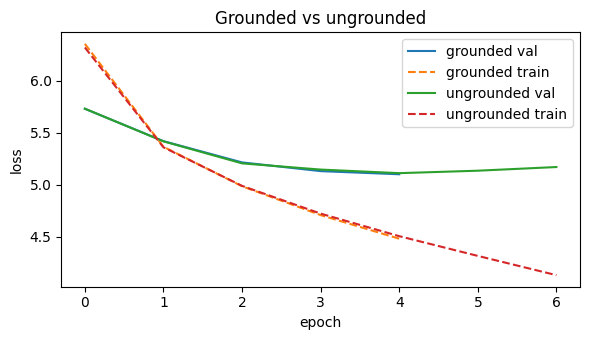

best val loss | grounded 5.103 | ungrounded 5.113


In [14]:
log_u = train_model(ungrounded, "ungrounded")

plt.figure(figsize=(6, 3.5))
for nm, lg_ in [("grounded", log_g), ("ungrounded", log_u)]:
    plt.plot(lg_["val"], label=f"{nm} val"); plt.plot(lg_["train"], "--", label=f"{nm} train")
plt.xlabel("epoch"); plt.ylabel("loss"); plt.legend(); plt.title("Grounded vs ungrounded")
plt.tight_layout(); plt.savefig("subtask3_loss.png", dpi=150); plt.show()
print(f"best val loss | grounded {log_g['best']:.3f} | ungrounded {log_u['best']:.3f}")

In [15]:
BLOCK = [PAD, SOS, SEP]
def to_words(seq):
    w = []
    for i in seq:
        if i == EOS: break
        w.append(itos[i])
    return w

@torch.no_grad()
def greedy_all(model, data, bs=128, sample=False, k=10, temp=0.8, desc="decode"):
    model.eval(); preds, mass = [None] * len(data), [None] * len(data)
    for b in tqdm(batch_idx(data, bs, False), desc=desc, leave=False):
        h_, hl, d_, dl, _ = collate([data[i] for i in b])
        mem, mask, h, c = model.encode(h_, hl, d_, dl); Sh = h_.size(1)
        tok = torch.full((len(b), 1), SOS); outs, ms = [], []
        for _ in range(R_MAXLEN):
            lg, h, c, a = model.step(tok, h, c, mem, mask); lg = lg[:, -1]; lg[:, BLOCK] = -1e9
            if sample:
                tv, ti = (lg / temp).topk(k, -1); tok = ti.gather(1, torch.multinomial(F.softmax(tv, -1), 1))
            else:
                tok = lg.argmax(-1, keepdim=True)
            outs.append(tok)
            ms.append(a[:, -1, Sh:].sum(-1) if model.use_doc else torch.zeros(len(b)))   # doc pe attention mass
        outs, ms = torch.cat(outs, 1).tolist(), torch.stack(ms, 1)
        for r, j in enumerate(b):
            p = to_words(outs[r]); preds[j] = p
            mass[j] = ms[r, :min(len(p) + 1, R_MAXLEN)].mean().item()
    return preds, mass

In [16]:
@torch.no_grad()
def beam_one(model, ex, k=3):
    model.eval()
    mem, mask, h, c = model.encode(torch.tensor([ex["h"]]), torch.tensor([len(ex["h"])]),
                                   torch.tensor([ex["d"]]), torch.tensor([len(ex["d"])]))
    seqs, scores, done = [[SOS]], torch.zeros(1), []
    for _ in range(R_MAXLEN):
        n = len(seqs)
        lg, h, c, _ = model.step(torch.tensor([[s[-1]] for s in seqs]), h, c, mem.expand(n, -1, -1), mask.expand(n, -1))
        lp = F.log_softmax(lg[:, -1], -1); lp[:, BLOCK] = -1e9
        top_s, top_i = (scores[:, None] + lp).view(-1).topk(2 * k)
        ns, nsc, nidx = [], [], []
        for s_, i in zip(top_s.tolist(), top_i.tolist()):
            b, w = divmod(i, V)
            if w == EOS: done.append((s_ / len(seqs[b]), seqs[b][1:]))
            elif w != seqs[b][-1]:                                   # immediate repetition block
                ns.append(seqs[b] + [w]); nsc.append(s_); nidx.append(b)
            if len(ns) == k: break
        if len(done) >= k or not ns: break
        seqs, scores = ns, torch.tensor(nsc); idx = torch.tensor(nidx); h, c = h[:, idx], c[:, idx]
    if not done: done = [(scores[i].item() / len(seqs[i]), seqs[i][1:]) for i in range(len(seqs))]
    return to_words(max(done, key=lambda x: x[0])[1])

def beam_all(model, data, k=3):
    return [beam_one(model, ex, k) for ex in tqdm(data, desc=f"beam k={k}", leave=False)]

In [17]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import linear_kernel

J = lambda t: " ".join(t)
vec = TfidfVectorizer(token_pattern=r"\S+", sublinear_tf=True)
vec.fit([J(s["hist"]) for s in train_s] + [J(s["resp"]) for s in train_s] + [J(s["doc"]) for s in train_s])
Xh = vec.transform([J(s["hist"]) for s in train_s]); Xr = vec.transform([J(s["resp"]) for s in train_s])

def retrieval(data, grounded_rerank=False, cand=20, w=1.0):
    S = linear_kernel(vec.transform([J(s["hist"]) for s in data]), Xh)
    preds = []
    for i, s in enumerate(tqdm(data, desc="retrieval", leave=False)):
        if not grounded_rerank:
            preds.append(train_s[int(S[i].argmax())]["resp"]); continue
        top = np.argsort(-S[i])[:cand]
        dsim = linear_kernel(vec.transform([J(s["doc"])]), Xr[top])[0]     # candidate reply <-> current document
        preds.append(train_s[int(top[(S[i][top] + w * dsim).argmax()])]["resp"])
    return preds

ret_plain, ret_doc = retrieval(test_s), retrieval(test_s, grounded_rerank=True)
print("done", len(ret_plain))

done 686


In [18]:
def lcs(a, b):
    dp = [0] * (len(b) + 1)
    for x in a:
        prev = 0
        for j, y in enumerate(b, 1):
            cur = dp[j]; dp[j] = prev + 1 if x == y else max(dp[j], dp[j - 1]); prev = cur
    return dp[-1]

def f1(p, r): return 0.0 if p + r == 0 else 2 * p * r / (p + r)
def rouge_l(h, r):
    if not h or not r: return 0.0
    l = lcs(h, r); return f1(l / len(h), l / len(r))
def rouge_1(h, r):
    if not h or not r: return 0.0
    o = sum((Counter(h) & Counter(r)).values()); return f1(o / len(h), o / len(r))
def distinct(preds, n):
    ng = [tuple(p[i:i + n]) for p in preds for i in range(len(p) - n + 1)]
    return len(set(ng)) / max(1, len(ng))

COMMON = {w for w, _ in Counter(w for s in train_s for w in s["resp"]).most_common(150)}
is_content = lambda w: bool(re.fullmatch(r"[a-z]{3,}", w)) and w not in COMMON
def doc_overlap(preds, data):                     # generated content words me se kitne document me hain
    tot = hit = 0
    for p, s in zip(preds, data):
        ds_ = DOCSET.get((s["widx"], s["sec"]), set())
        for w in p:
            if is_content(w): tot += 1; hit += w in ds_
    return 100 * hit / max(1, tot)

refs = [s["resp"] for s in test_s]
def bleu_of(preds, refs_=refs):
    return sacrebleu.corpus_bleu([J(p) for p in preds], [[J(r) for r in refs_]], tokenize="none", force=True).score

def evaluate(name, preds, data=test_s):
    rf = [s["resp"] for s in data]
    return {"model": name, "BLEU": bleu_of(preds, rf),
            "ROUGE-1": 100 * np.mean([rouge_1(p, r) for p, r in zip(preds, rf)]),
            "ROUGE-L": 100 * np.mean([rouge_l(p, r) for p, r in zip(preds, rf)]),
            "distinct-1": distinct(preds, 1), "distinct-2": distinct(preds, 2),
            "avg_len": np.mean([len(p) for p in preds]),
            "unk%": 100 * np.mean([w == "<unk>" for p in preds for w in p]) if any(preds) else 0,
            "doc_overlap%": doc_overlap(preds, data)}

P = {}
P["Retrieval (history only)"], P["Retrieval (+doc rerank)"] = ret_plain, ret_doc
P["Ungrounded seq2seq, greedy"], _ = greedy_all(ungrounded, test_s, desc="ungrounded greedy")
P["Grounded seq2seq, greedy"], mass_real = greedy_all(grounded, test_s, desc="grounded greedy")
P["Ungrounded seq2seq, beam-3"] = beam_all(ungrounded, test_s)
P["Grounded seq2seq, beam-3"] = beam_all(grounded, test_s)

rows = [evaluate("Human reference", refs)] + [evaluate(k, v) for k, v in P.items()]
table = pd.DataFrame(rows).set_index("model").round(2)
display(table)

,BLEU,ROUGE-1,ROUGE-L,distinct-1,distinct-2,avg_len,unk%,doc_overlap%
model,,,,,,,,
Human reference,100.00,100.00,100.00,0.21,0.69,14.70,0.0,12.19
Retrieval (history only),0.33,9.68,8.45,0.16,0.47,14.61,0.0,3.84
Retrieval (+doc rerank),0.30,10.53,9.11,0.15,0.44,16.06,0.0,11.96
"Ungrounded seq2seq, greedy",1.18,12.61,11.09,0.01,0.02,14.87,0.0,2.59
"Grounded seq2seq, greedy",1.14,13.22,11.40,0.01,0.02,13.83,0.0,8.11
"Ungrounded seq2seq, beam-3",1.01,12.59,11.43,0.00,0.01,17.60,0.0,0.00
"Grounded seq2seq, beam-3",1.01,11.85,10.70,0.01,0.01,17.21,0.0,5.41


In [19]:
# give wrong doc data , if model uses doc then score should decrease
def wrong_doc_samples(data):
    out = []
    for s in data:
        while True:
            o = random.choice(data)
            if o["widx"] != s["widx"]: break
        out.append(dict(s, d=o["d"]))
    return out

random.seed(0)
shuf = wrong_doc_samples(test_s)
p_shuf, mass_shuf = greedy_all(grounded, shuf, desc="wrong doc")
empty = [dict(s, d=[UNK]) for s in test_s]
p_empty, _ = greedy_all(grounded, empty, desc="empty doc")

abl = pd.DataFrame([evaluate("Grounded, correct doc", P["Grounded seq2seq, greedy"]),
                    evaluate("Grounded, WRONG doc", p_shuf),
                    evaluate("Grounded, empty doc", p_empty),
                    evaluate("Ungrounded (no doc encoder)", P["Ungrounded seq2seq, greedy"])]).set_index("model").round(2)
display(abl[["BLEU", "ROUGE-1", "ROUGE-L", "doc_overlap%"]])

# 2) Attention mass jo document pe jaata hai (joint softmax ka fayda)
print(f"Mean attention mass on document: correct doc {np.mean(mass_real):.3f} | wrong doc {np.mean(mass_shuf):.3f}")

# 3) Wrong doc ke saath kitne outputs badal gaye
chg = np.mean([a != b for a, b in zip(P["Grounded seq2seq, greedy"], p_shuf)]) * 100
print(f"Outputs changed when document swapped: {chg:.1f}%")

,BLEU,ROUGE-1,ROUGE-L,doc_overlap%
model,,,,
"Grounded, correct doc",1.14,13.22,11.40,8.11
"Grounded, WRONG doc",1.24,12.90,11.06,3.62
"Grounded, empty doc",0.70,10.89,9.66,0.32
Ungrounded (no doc encoder),1.18,12.61,11.09,2.59


Mean attention mass on document: correct doc 0.577 | wrong doc 0.576
Outputs changed when document swapped: 59.8%


In [20]:
def group_table(pred_dict, keyfn, data=test_s):
    groups = [keyfn(s) for s in data]; rows = []
    for g in sorted(set(groups)):
        idx = [i for i, x in enumerate(groups) if x == g]
        row = {"group": g, "n": len(idx), "avg CMI (ref)": np.mean([cmi(data[i]["resp"]) for i in idx]).round(1)}
        for nm, p in pred_dict.items():
            row[nm + " BLEU"] = round(bleu_of([p[i] for i in idx], [refs[i] for i in idx]), 2)
            row[nm + " R-L"] = round(100 * np.mean([rouge_l(p[i], refs[i]) for i in idx]), 1)
        rows.append(row)
    return pd.DataFrame(rows).set_index("group")

cmp_preds = {"Grounded": P["Grounded seq2seq, greedy"], "Ungrounded": P["Ungrounded seq2seq, greedy"]}
print("== Reference reply ke language mix ke hisaab se ==")
display(group_table(cmp_preds, lambda s: mix_group(s["resp"])))
print("== Kya speaker ne document dekha tha? ==")
display(group_table(cmp_preds, lambda s: "saw doc" if s["saw"] else "no doc"))

== Reference reply ke language mix ke hisaab se ==


,n,avg CMI (ref),Grounded BLEU,Grounded R-L,Ungrounded BLEU,Ungrounded R-L
group,,,,,,
mixed,323,35.9,0.63,10.6,0.76,10.6
mostly-EN,8,14.3,0.50,2.8,0.44,4.1
mostly-HI,310,9.9,1.60,12.9,1.60,11.9
short,45,5.6,0.13,8.2,0.13,10.0


== Kya speaker ne document dekha tha? ==


,n,avg CMI (ref),Grounded BLEU,Grounded R-L,Ungrounded BLEU,Ungrounded R-L
group,,,,,,
no doc,171,18.9,1.79,11.6,1.60,10.4
saw doc,515,22.9,0.74,11.3,0.95,11.3


HIST      : namaste <sep> namaste <sep> the shape of water ek bahut achchi movie hai .
DOC       : the shape of water <sep> the shape of water . the shape of water is a 2017 american fantasy drama film directed by guillermo del ...
REFERENCE : meme pahal is movie ke baare mei nahi suna
GROUNDED  : kya aap movie ko dekha ?
UNGROUNDED: haan , mujhe lagata hai ki yah movie ke baare mein hai .
RETRIEVAL : kya aapne wonder woman film dekha hai 

HIST      : haan aur history ne mujhe bandh k rakha <sep> same yaha bhi <sep> haan mujhe wapas jake use dekhne ka man karwa diya
DOC       : wonder woman <sep> initially forbidding diana to train as a warrior , hippolyta allows her sister antiope to train diana , only more rigorously than ...
REFERENCE : kam se kam maine do baar dekha , it was that good . mujhe female superheros bahut pasand hai mujhe bhi
GROUNDED  : oh , mujhe lagta hai ki ye movie movie hai
UNGROUNDED: mujhe lagta hai ki wo ek ek ek ek tale tale hai
RETRIEVAL : hi 

HIST      : mo

Sampling sample: ['yes ye ek interesting hai . ye movie ki movie movie ki is movie par movie ki', 'kya kya tum tum movie movies ho ?', 'i agree . i guess']


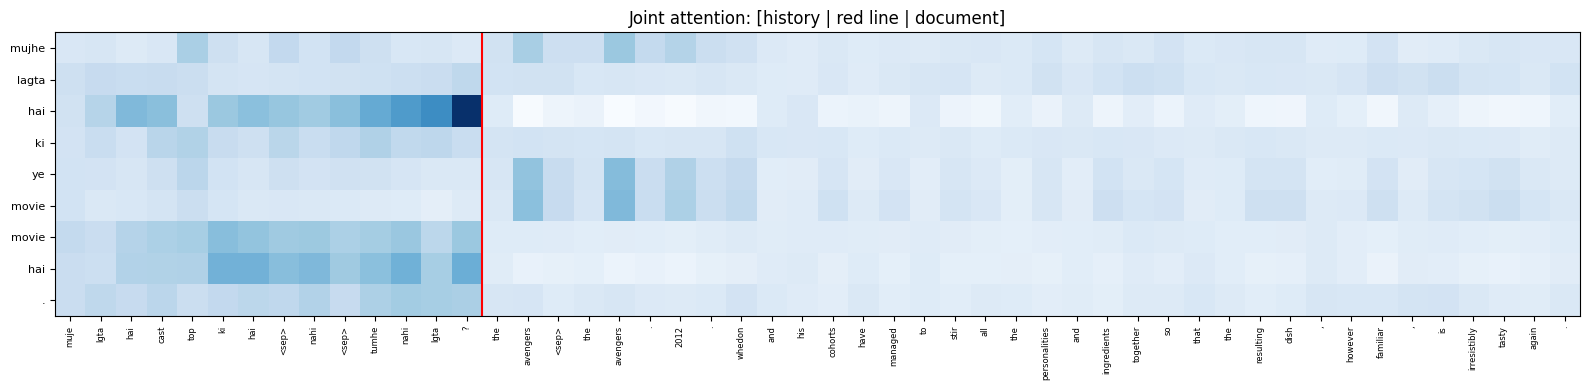

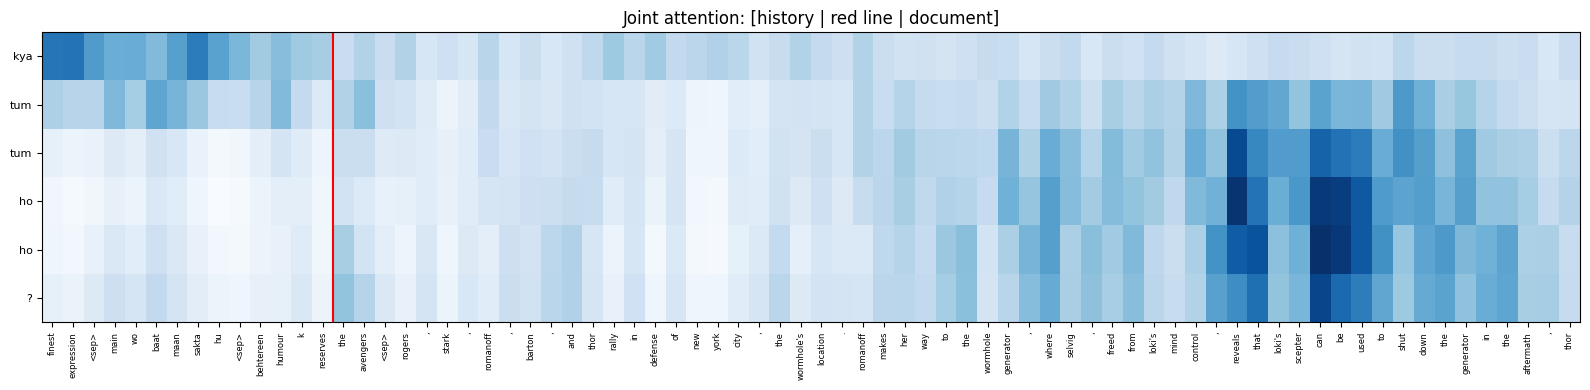

In [21]:
random.seed(3)
for i in random.sample(range(len(test_s)), 6):
    s = test_s[i]
    print("HIST      :", J(s["hist"][-30:]))
    print("DOC       :", J(s["doc"][:25]), "...")
    print("REFERENCE :", J(s["resp"]))
    print("GROUNDED  :", J(P["Grounded seq2seq, greedy"][i]))
    print("UNGROUNDED:", J(P["Ungrounded seq2seq, greedy"][i]))
    print("RETRIEVAL :", J(P["Retrieval (+doc rerank)"][i]), "\n")

# Diversity ke liye top-k sampling (grounded)
torch.manual_seed(0)
samp, _ = greedy_all(grounded, test_s[:200], sample=True, desc="sampling")
print("Sampling sample:", [J(p) for p in samp[:3]])

def show_attn(model, ex, path):
    model.eval(); h_, hl, d_, dl, _ = collate([ex])
    with torch.no_grad():
        mem, mask, h, c = model.encode(h_, hl, d_, dl)
        tok, out, A = torch.tensor([[SOS]]), [], []
        for _ in range(R_MAXLEN):
            lg, h, c, a = model.step(tok, h, c, mem, mask); lg = lg[:, -1]; lg[:, BLOCK] = -1e9
            nxt = lg.argmax(-1)
            if nxt.item() == EOS: break
            out.append(itos[nxt.item()]); A.append(a[0, -1].numpy()); tok = nxt[:, None]
    if not out: return
    src = [itos[i] for i in ex["h"]] + [itos[i] for i in ex["d"]]
    plt.figure(figsize=(16, 4)); plt.imshow(np.array(A), cmap="Blues", aspect="auto")
    plt.axvline(len(ex["h"]) - 0.5, color="red", lw=1.5)
    plt.xticks(range(len(src)), src, rotation=90, fontsize=6); plt.yticks(range(len(out)), out, fontsize=8)
    plt.title("Joint attention: [history | red line | document]"); plt.tight_layout()
    plt.savefig(path, dpi=150); plt.show()

show_attn(grounded, test_s[5], "subtask3_attn_1.png")
show_attn(grounded, test_s[20], "subtask3_attn_2.png")

In [22]:
out = {"main_table": table.reset_index().to_dict("records"),
       "ablation": abl.reset_index().to_dict("records"),
       "doc_attention_mass": {"correct_doc": float(np.mean(mass_real)), "wrong_doc": float(np.mean(mass_shuf))},
       "sizes": {"train": len(train_s), "val": len(val_s), "test": len(test_s), "vocab": V},
       "best_val_loss": {"grounded": log_g["best"], "ungrounded": log_u["best"]}}
json.dump(out, open("subtask3_results.json", "w"), indent=2, default=float)
table.to_csv("subtask3_main_table.csv"); print("saved")

saved
